Etapa 1: Conocer y Preparar los Datos
¿Qué vamos a hacer y para qué sirve?

Antes de calcular cualquier promedio o tirar una regresión, en el sector privado el primer paso de un analista de datos es la auditoría e ingestión de datos.

In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/TienChih/tbil-stats/main/data/loans_full_schema.csv"
df = pd.read_csv(url)

In [3]:
df.shape

(10000, 55)

In [4]:
df.head(5)

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [5]:
df.info


<bound method DataFrame.info of                     emp_title  emp_length state homeownership  annual_income  \
0     global config engineer          3.0    NJ      MORTGAGE        90000.0   
1      warehouse office clerk        10.0    HI          RENT        40000.0   
2                    assembly         3.0    WI          RENT        40000.0   
3            customer service         1.0    PA          RENT        30000.0   
4        security supervisor         10.0    CA          RENT        35000.0   
...                       ...         ...   ...           ...            ...   
9995                   owner         10.0    TX          RENT       108000.0   
9996                 director         8.0    PA      MORTGAGE       121000.0   
9997                toolmaker        10.0    CT      MORTGAGE        67000.0   
9998                  manager         1.0    WI      MORTGAGE        80000.0   
9999       operations analyst         3.0    CT          RENT        66000.0   

      verified_income  debt_to_income  annual_income_joint  \
0            Verified           18.01                  NaN   
1        Not Verified            5.04                  NaN   
2     Source Verified           21.15                  NaN   
3        Not Verified           10.16                  NaN   
4            Verified           57.96              57000.0   
...               ...             ...                  ...   
9995  Source Verified           22.28                  NaN   
9996         Verified           32.38                  NaN   
9997         Verified           45.26             107000.0   
9998  Source Verified           11.99                  NaN   
9999     Not Verified           20.82                  NaN   

     verification_income_joint  debt_to_income_joint  ...  sub_grade  \
0                          NaN                   NaN  ...         C3   
1                          NaN                   NaN  ...         C1   
2                          NaN                   NaN  ...         D1   
3                          NaN                   NaN  ...         A3   
4                     Verified                 37.66  ...         C3   
...                        ...                   ...  ...        ...   
9995                       NaN                   NaN  ...         A4   
9996                       NaN                   NaN  ...         D3   
9997           Source Verified                 29.57  ...         E2   
9998                       NaN                   NaN  ...         A1   
9999                       NaN                   NaN  ...         B4   

      issue_month  loan_status  initial_listing_status  disbursement_method  \
0        Mar-2018      Current                   whole                 Cash   
1        Feb-2018      Current                   whole                 Cash   
2        Feb-2018      Current              fractional                 Cash   
3        Jan-2018      Current                   whole                 Cash   
4        Mar-2018      Current                   whole                 Cash   
...           ...          ...                     ...                  ...   
9995     Jan-2018      Current                   whole                 Cash   
9996     Feb-2018      Current                   whole                 Cash   
9997     Feb-2018      Current              fractional                 Cash   
9998     Feb-2018      Current                   whole                 Cash   
9999     Feb-2018      Current                   whole                 Cash   

       balance  paid_total  paid_principal  paid_interest  paid_late_fees  
0     27015.86     1999.33          984.14        1015.19             0.0  
1      4651.37      499.12          348.63         150.49             0.0  
2      1824.63      281.80          175.37         106.43             0.0  
3     18853.26     3312.89         2746.74         566.15             0.0  
4     21430.15     2324.65         1569.85         754.80           

Diccionario de variables y unidades de medida

Es fundamental hacer esta pregunta antes de modelar:


*   interest_rate: Es la Tasa Nominal Anual (APR)
expresada en porcentaje. Si el valor es 14.07, significa 14,07% anual.


*   term: Es el plazo del crédito expresado en meses. Solo toma dos valores en esta base: 36 (3 años) o 60 (5 años).
*   emp_length: Es la antigüedad laboral en el puesto actual expresada en años (ej. 3, 5, 10).
public_record_bankrupt: Es un conteo de quiebras en el registro público del cliente. La mayoría tiene 0 (nunca se declaró en quiebra) y algunos tienen 1 o más.



*   debt_to_income (DTI): Es el ratio deuda/ingreso expresado en porcentaje (cuota mensual de deudas
÷
÷ ingreso mensual
×
100
×100).
*   annual_income: Ingreso bruto anual declarado por el cliente en dólares.







In [6]:
columnas_seleccionadas = ['interest_rate', 'debt_to_income', 'annual_income','grade','term','loan_amount','homeownership','emp_length', 'public_record_bankrupt' ]
df_subset = df[columnas_seleccionadas].copy()

In [7]:
df_subset.isna().sum()

,0
interest_rate,0
debt_to_income,24
annual_income,0
grade,0
term,0
loan_amount,0
homeownership,0
emp_length,817
public_record_bankrupt,0


Consigna 1.3 — Limpieza de nulos y radiografía de variables

In [8]:
df_subset = df_subset.dropna(subset=['debt_to_income'])

In [9]:
df_subset.shape

(9976, 9)

In [10]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [11]:
df_subset.describe()

,interest_rate,debt_to_income,annual_income,term,loan_amount,emp_length,public_record_bankrupt
count,9976.00,9976.00,9976.00,9976.00,9976.00,9182.00,9976.00
mean,12.42,19.31,79412.74,43.27,16357.53,5.93,0.12
std,5.00,15.00,64695.24,11.03,10301.61,3.70,0.34
min,5.31,0.00,3000.00,36.00,1000.00,0.00,0.00
25%,9.43,11.06,45000.00,36.00,8000.00,2.00,0.00
50%,11.98,17.57,65000.00,36.00,14500.00,6.00,0.00
75%,15.05,25.00,95000.00,60.00,24000.00,10.00,0.00
max,30.94,469.09,2300000.00,60.00,40000.00,10.00,3.00


In [12]:
df_subset['homeownership'].value_counts()

,count
homeownership,
MORTGAGE,4778
RENT,3848
OWN,1350


In [13]:
df_subset['grade'].value_counts()

,count
grade,
B,3032
C,2649
A,2454
D,1438
E,334
F,57
G,12


In [14]:
import numpy as np

# Creamos la nueva variable
df_subset['log_annual_income'] = np.log(df_subset['annual_income'])

# Comparamos ambas variables lado a lado
df_subset[['annual_income', 'log_annual_income']].describe()

,annual_income,log_annual_income
count,9976.00,9976.00
mean,79412.74,11.10
std,64695.24,0.60
min,3000.00,8.01
25%,45000.00,10.71
50%,65000.00,11.08
75%,95000.00,11.46
max,2300000.00,14.65


Etapa 2: Análisis Exploratorio de Negocio (EDA)
¿Qué vamos a hacer y para qué sirve?

Ahora nos ponemos el traje de analista de negocio/pricing. En un banco o fintech, antes de presentar un modelo econométrico, tu jefe o el director de riesgo te va a pedir: "Mostrame cómo se comporta la cartera: ¿quién paga más tasa, cuánto más cara es y qué relación visual existe entre el riesgo y el precio?"

Consigna 2.1 — La escala de riesgo y la tasa de interés

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df_subset.groupby('grade')['interest_rate'].agg(['mean', 'median', 'count'])

,mean,median,count
grade,,,
A,6.74,6.72,2454
B,10.52,10.42,3032
C,14.18,14.07,2649
D,19.12,19.03,1438
E,25.10,24.85,334
F,29.41,28.72,57
G,30.80,30.79,12



  
1. df_subset (La tabla base)

  

Es el DataFrame donde tenemos nuestras columnas limpias.


  
2. .groupby('grade') (El criterio de división)

  

  
¿Qué hace? Imaginate que tenés los 9.976 formularios de préstamos impresos arriba del escritorio. Este comando le dice a Python: "Separá todos los papeles en 7 pilas distintas según la letra de la calificación (A, B, C, D, E, F, G)".

  
El argumento: Le pasás entre comillas el nombre de la columna que querés usar para armar los grupos.

  

  
3. ['interest_rate'] (La columna a medir)

  

  
¿Qué hace? Cada una de las 7 pilas de papeles tiene un montón de columnas (ingreso, monto, deuda, etc.). Con los corchetes ['interest_rate'] le decís: "De todas las columnas, mirá únicamente el número de la tasa de interés".

  
Si no pusieras esto, Python intentaría calcularle el promedio a todas las columnas de la tabla (incluso a las que son texto, lo cual daría error).

  

  
4. .agg(['mean', 'median', 'count']) (Las funciones de cálculo)

  

  
¿Qué hace? agg es la abreviatura de aggregate (agregar o resumir). Le pide a la computadora: "Ahora tomá cada pila por separado y calculame un resumen con estas estadísticas específicas".

  
El argumento: Le pasás una lista [...] con los nombres de las funciones estadísticas que querés en formato texto:
  

  
'mean': La media aritmética (promedio).

  
'median': El percentil 50 (la mediana, inmune a valores extremos).

  
'count': Cuántos préstamos hay en cada pila (el tamaño muestral
𝑁
N).

  
(Si quisieras el desvío estándar o el valor mínimo, podrías sumar 'std', 'min', etc.).

  

  

  

  

  
La intuición en lenguaje humano:

  

  

"Tomá la tabla df_subset, separala en grupos según la nota crediticia (grade), mirá la tasa de interés (interest_rate) de cada uno, y devolveme una tabla resumen con el promedio, la mediana y la cantidad de casos de cada grupo."

In [17]:
df_subset.groupby('grade')['interest_rate'].agg(['mean', 'median', 'count'])

,mean,median,count
grade,,,
A,6.74,6.72,2454
B,10.52,10.42,3032
C,14.18,14.07,2649
D,19.12,19.03,1438
E,25.10,24.85,334
F,29.41,28.72,57
G,30.80,30.79,12


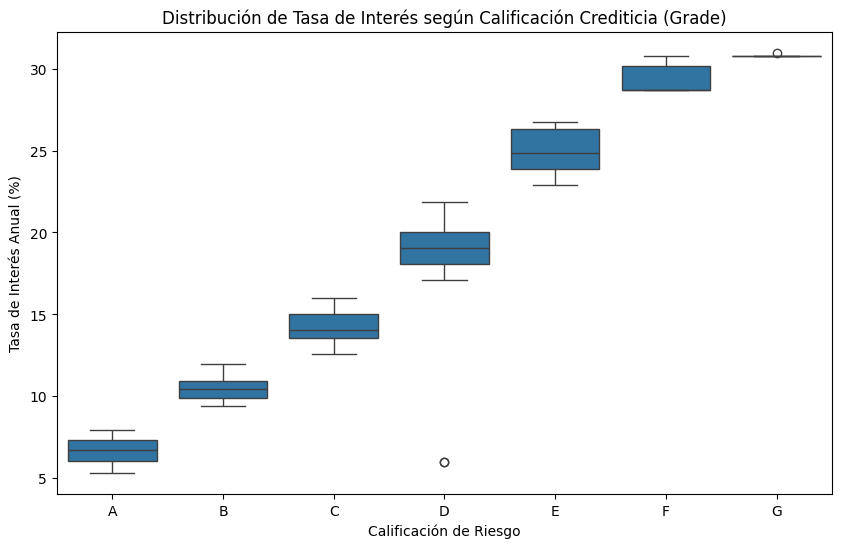

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_subset, x='grade', y='interest_rate', order=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.title('Distribución de Tasa de Interés según Calificación Crediticia (Grade)')
plt.xlabel('Calificación de Riesgo')
plt.ylabel('Tasa de Interés Anual (%)')
plt.show()

Consigna 2.2 — La Estructura Temporal y el Plazo ¿Cobra la plataforma una tasa más alta por prestar a mayor plazo, incluso a personas que tienen la misma calificación crediticia?

---
Podemos pedirle a seaborn que separe cada nota crediticia (grade) en dos cajitas usando el argumento hue='term':


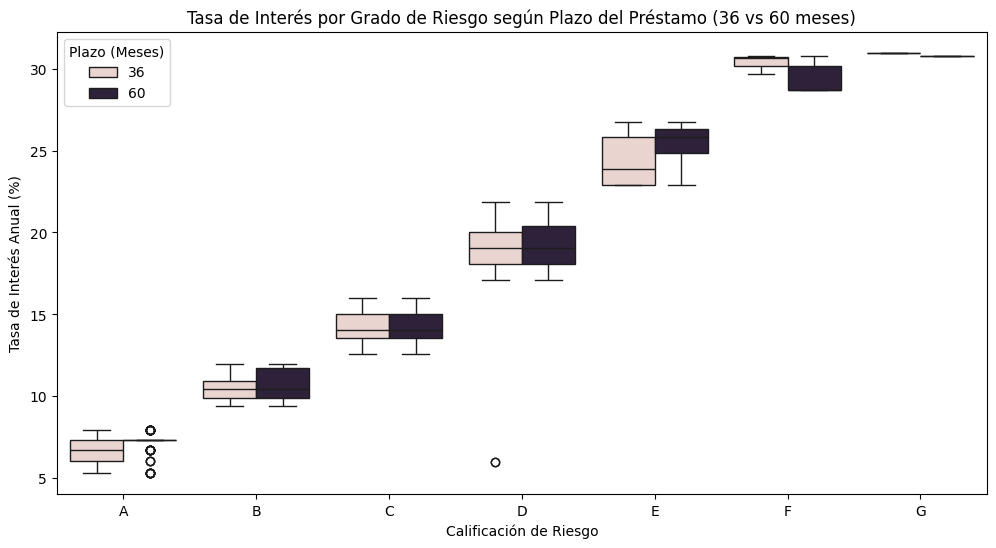

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_subset, x='grade', y='interest_rate', hue='term',
            order=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.title('Tasa de Interés por Grado de Riesgo según Plazo del Préstamo (36 vs 60 meses)')
plt.xlabel('Calificación de Riesgo')
plt.ylabel('Tasa de Interés Anual (%)')
plt.legend(title='Plazo (Meses)')
plt.show()

In [20]:
df_subset.groupby(['grade', 'term'])['interest_rate'].mean().unstack()

term,36,60
grade,,
A,6.71,7.23
B,10.51,10.56
C,14.20,14.15
D,18.99,19.26
E,24.41,25.44
F,30.36,29.36
G,30.94,30.79


Consigna 2.3 — La Matriz de Correlaciones (Cierre de Etapa 2)

Para cerrar el análisis exploratorio y pasar al modelado econométrico, necesitamos ver cómo interactúan entre sí las variables financieras continuas.

En particular queremos saber:

¿Los clientes más endeudados (debt_to_income) pagan efectivamente más tasa?
¿Los clientes con ingresos más altos (log_annual_income) consiguen mejores tasas?
¿Préstamos más grandes (loan_amount) pagan más o menos tasa?

In [21]:
variables_continuas = ['interest_rate', 'debt_to_income', 'loan_amount', 'log_annual_income']
matriz_corr = df_subset[variables_continuas].corr()
matriz_corr

,interest_rate,debt_to_income,loan_amount,log_annual_income
interest_rate,1.00,0.14,0.07,-0.13
debt_to_income,0.14,1.00,0.06,-0.29
loan_amount,0.07,0.06,1.00,0.41
log_annual_income,-0.13,-0.29,0.41,1.00


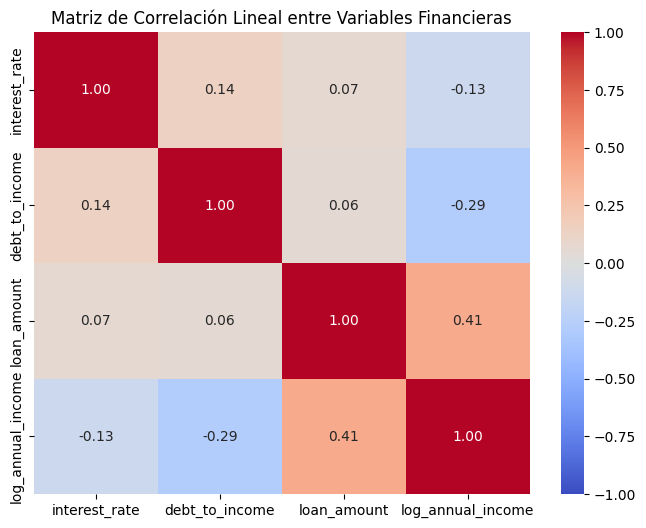

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación Lineal entre Variables Financieras')
plt.show()

Etapa 3: Modelado Estadístico y Econometría Básica (OLS)
¿Qué vamos a hacer y para qué sirve?

Hasta ahora vimos relaciones de a dos variables (bivariadas). Ahora vamos a dar el salto que separa a un usuario básico de Excel de un economista o científico de datos: el análisis multivariado mediante Mínimos Cuadrados Ordinarios (MCO / OLS).

La regresión nos permite aislar el efecto de cada variable bajo la condición clásica de la economía: Ceteris Paribus (manteniendo todo lo demás constante).

Usaremos la librería statsmodels, que es la herramienta predilecta para economistas porque genera salidas idénticas a programas como Stata o R.

Consigna 3.1 — Regresión Lineal Simple: Tasa vs. Deuda/Ingreso

Arrancamos con el modelo más básico posible: estimar cómo el ratio Deuda/Ingreso (debt_to_income) impacta en la tasa de interés (interest_rate).

interest_rate
𝑖
=
𝛽
0
+
𝛽
1
⋅
debt_to_income
𝑖
+
𝜀
𝑖
interest_rate
i
	​

=β
0
	​ +β 1
	​
⋅debt_to_income
i
	​
    +ε
i
	​

In [23]:
import statsmodels.formula.api as smf

# Definimos y ajustamos el modelo
modelo_simple = smf.ols(formula='interest_rate ~ debt_to_income', data=df_subset).fit()

# Imprimimos la tabla de resultados econométricos
print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     204.2
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           7.05e-46
Time:                        22:00:11   Log-Likelihood:                -30105.
No. Observations:                9976   AIC:                         6.021e+04
Df Residuals:                    9974   BIC:                         6.023e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         11.5114      0.081    142.

Consigna 3.2 — Regresión Múltiple: El poder del Ceteris Paribus

Vamos a sumar al modelo las otras variables financieras clave: el ingreso en escala logarítmica (log_annual_income), el monto del préstamo (loan_amount) y el plazo (term):

interest_rate=
𝛽0
+
𝛽1⋅debt_to_income
+
𝛽⋅
log_annual_income
+
𝛽
3
⋅
loan_amount
+
𝛽
4
⋅
term
+
𝜀


In [24]:
formula_multiple = 'interest_rate ~ debt_to_income + log_annual_income + loan_amount + term'
modelo_multiple = smf.ols(formula=formula_multiple, data=df_subset).fit()
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.161
Method:                 Least Squares   F-statistic:                     478.0
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:00:11   Log-Likelihood:                -29331.
No. Observations:                9976   AIC:                         5.867e+04
Df Residuals:                    9971   BIC:                         5.871e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            15.8448      1.01

Consigna 3.3 — El Modelo Completo de Negocio (Dummies con C())

las variables que definen el precio en este mercado son las categóricas (grade y homeownership).

En econometría, para incluir variables de texto las transformamos en variables binarias o dummies (0 o 1). En statsmodels no hace falta crearlas a mano: basta con envolver la columna con C(...) para que Python elija automáticamente una categoría de referencia y cree las demás.

interest_rate∼DTI+log(Ingreso)+loan amount+Term+C(grade)+C(homeownership)

In [25]:
formula_completa = 'interest_rate ~ debt_to_income + log_annual_income + loan_amount + term + C(grade) + C(homeownership)'
modelo_completo = smf.ols(formula=formula_completa, data=df_subset).fit()
print(modelo_completo.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                 1.623e+04
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:00:11   Log-Likelihood:                -15130.
No. Observations:                9976   AIC:                         3.029e+04
Df Residuals:                    9963   BIC:                         3.038e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Etapa 4: Informe Ejecutivo